In [ ]:
import numpy as np
import pandas as pd
from scipy.stats import norm

tempos = [
    12, 15, 14, 16, 18, 12, 20, 22, 14, 15,
    16, 18, 19, 21, 17, 13, 14, 15, 16, 18,
    19, 20, 12, 15, 14, 13, 16, 18, 19, 21,
    22, 23, 24, 25, 20, 19, 18, 15, 14, 16,
    17, 15, 14, 12, 13, 18, 19, 20, 21, 22
]

# tabela
df = pd.DataFrame({
    "Tempos_execucao": tempos
})


media = df["Tempos_execucao"].mean()

desvio = df["Tempos_execucao"].std()


n = len(tempos)

print("Média:", media)
print("Desvio padrão:", desvio)
print("Quantidade de dados:", n)

Média: 17.18
Desvio padrão: 3.390803889995434
Quantidade de dados: 50


QUESTÃO 4 

In [2]:
# valores de Z
z15 = (15 - media) / desvio
z20 = (20 - media) / desvio

# probabilidade entre 15 e 20 ms
probabilidade_4 = norm.cdf(z20) - norm.cdf(z15)

print("Z para 15 ms:", z15)
print("Z para 20 ms:", z20)
print("Probabilidade:", probabilidade_4)
print("Porcentagem:", probabilidade_4 * 100, "%")

Z para 15 ms: -0.6429153884222232
Z para 20 ms: 0.8316611905278302
Probabilidade: 0.5370603919159443
Porcentagem: 53.706039191594435 %


entre 15 ms e 20 ms é aproximadamente 53,71%

QUESTÃO 5

In [3]:
# percentil 90
percentil_90 = norm.ppf(
    0.90,
    loc=media,
    scale=desvio
)

print("Percentil 90:", percentil_90, "ms")

Percentil 90: 21.52549003367837 ms


QUESTÃO 6

In [4]:
# valor crítico para 95% de confiança
z = 1.96

# erro padrão da média
erro_padrao = desvio / np.sqrt(n)

# margem de erro
margem_erro = z * erro_padrao

# limites do intervalo
limite_inferior = media - margem_erro
limite_superior = media + margem_erro

print("Média:", media)
print("Erro padrão:", erro_padrao)
print("Margem de erro:", margem_erro)
print("Limite inferior:", limite_inferior)
print("Limite superior:", limite_superior)

Média: 17.18
Erro padrão: 0.47953208485789905
Margem de erro: 0.9398828863214821
Limite inferior: 16.24011711367852
Limite superior: 18.11988288632148


QUESTÃO 7

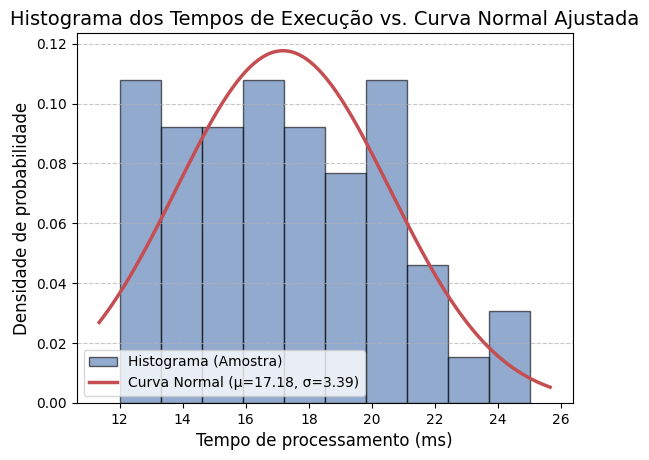

In [6]:
import matplotlib.pyplot as plt

plt.hist(tempos, bins=10, density=True, alpha=0.6, color='#4C72B0', edgecolor='black', label='Histograma (Amostra)')

xmin, xmax = plt.xlim()
eixo_x = np.linspace(xmin, xmax, 100)
eixo_y = norm.pdf(eixo_x, media, desvio)

plt.plot(eixo_x, eixo_y, color='#C44E52', linewidth=2.5, 
         label=f'Curva Normal (μ={media:.2f}, σ={desvio:.2f})')


plt.title('Histograma dos Tempos de Execução vs. Curva Normal Ajustada', fontsize=14)
plt.xlabel('Tempo de processamento (ms)', fontsize=12)
plt.ylabel('Densidade de probabilidade', fontsize=12)
plt.legend()
plt.grid(axis='y', linestyle='--', alpha=0.7)

plt.show()

QUESTÃO 8


Com base na análise visual do histograma sobreposto à curva normal teórica, observa-se que o desempenho do algoritmo apresenta uma variabilidade que compromete parcialmente a sua previsibilidade em execuções individuais. Embora o modelo gaussiano ajustado utilize a média de 17,18 ms e o desvio padrão de 3,39 ms para descrever a tendência central, o gráfico revela que a amostra real não segue um formato de sino perfeito e perfeitamente simétrico. A distribuição dos tempos de processamento é irregular e algo dispersa, formando blocos de concentração em diferentes faixas, havendo picos de densidade perceptíveis tanto no início (próximo aos 12 ms e 13 ms) quanto em valores mais altos (na faixa dos 20 ms aos 21 ms). Além dessa flutuação na região central, o gráfico demonstra uma extensão dos dados à direita, com execuções que chegam a atingir até 25 ms, evidenciando atrasos esporádicos. Conclui-se, portanto, que o algoritmo não apresenta um desempenho estritamente consistente, pois oscila de forma perceptível entre execuções rápidas e mais demoradas, tornando-se menos adequado para sistemas críticos que exigem tempos de resposta altamente precisos e sem flutuações.
